In [1]:
from PIL import Image
from matplotlib import pyplot as plt
import torch.nn as nn
from torchvision.transforms.functional import to_tensor

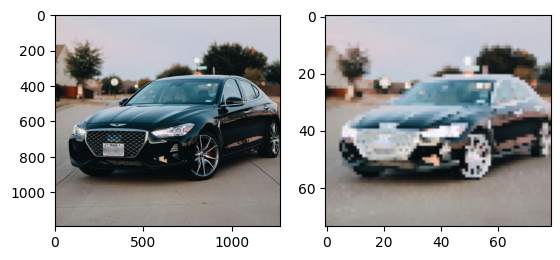

In [9]:
image = Image.open("data/car.png")  # переменная для загрузки car.png с помощью PIL
image_tensor = to_tensor(image).unsqueeze(0)  # переменная для изображения, преобразованного в тензор
# ваш код для приведения тензора изображения к подходящей размерности
result = nn.MaxPool2d(16)(image_tensor).detach() # переменная для результатов макс-пулинга

# визуализация
fig = plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(image)

plt.subplot(1, 2, 2)
plt.imshow(result[0].permute(1, 2, 0))

## LeNet и AlexNet

In [ ]:
import torch.nn as nn

LeNet5 = nn.Sequential(
    # Первый свёрточный блок
    nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=2),
    nn.Tanh(), # Сигмоидальная функция, похожая на используемую в LeNet
    nn.AvgPool2d(kernel_size=2, stride=2),
    
    # Второй свёрточный блок
    nn.Conv2d(6, 16, kernel_size=5, stride=1, padding=0),
    nn.Tanh(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    
    nn.Flatten(),

    #Полносвязная часть
    nn.Linear(400, 120),
    nn.Tanh(),
    nn.Linear(120, 84),
    nn.Tanh(),
    nn.Linear(84, 10),
    nn.Softmax(dim=1)
)

print("Архитектура модели:", LeNet5)
print("Количество параметров:", sum(p.numel() for p in LeNet5.parameters()))

Архитектура модели: Sequential(
  (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (1): Tanh()
  (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (4): Tanh()
  (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=400, out_features=120, bias=True)
  (8): Tanh()
  (9): Linear(in_features=120, out_features=84, bias=True)
  (10): Tanh()
  (11): Linear(in_features=84, out_features=10, bias=True)
  (12): Softmax(dim=1)
)
Количество параметров: 61706


In [37]:
x = 28
x = np.floor( (x - 5 + 2 * 2) / 1 ) + 1
x = np.floor( (x - 2 + 2 * 0) / 2 ) + 1
x = np.floor( (x - 5 + 2 * 0) / 1 ) + 1
x = np.floor( (x - 2 + 2 * 0) / 2 ) + 1

print(x * x * 16)

400.0


In [64]:
# Используйте архитектуру LeNet в качестве основы
AlexNet = nn.Sequential(
    nn.Conv2d(3, 96, kernel_size=11, stride=4),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    nn.Conv2d(96, 256, kernel_size=5, padding=2, stride=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    
    nn.Conv2d(256, 384, kernel_size=3, padding=1, stride=1),
    nn.ReLU(),
    
    nn.Conv2d(384, 384, kernel_size=3, padding=1, stride=1),
    nn.ReLU(),

    nn.Conv2d(384, 256, kernel_size=3, padding=1, stride=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    
    nn.Flatten(),
    nn.Dropout(),

    nn.Linear(6400, 4096),
    nn.ReLU(),
    nn.Dropout(),

    nn.Linear(4096, 4096),
    nn.ReLU(),

    nn.Linear(4096, 1000),
    nn.Softmax(dim=1)
)

print("Архитектура модели:", AlexNet)
print("Количество параметров:", sum(p.numel() for p in AlexNet.parameters()))

Архитектура модели: Sequential(
  (0): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): ReLU()
  (8): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): ReLU()
  (10): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU()
  (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (13): Flatten(start_dim=1, end_dim=-1)
  (14): Dropout(p=0.5, inplace=False)
  (15): Linear(in_features=6400, out_features=4096, bias=True)
  (16): ReLU()
  (17): Dropout(p=0.5, inplace=False)
  (18): Linear(in_features=4096, out_features=4096, bias=True)
  (19): ReLU()
  (20): Linear(in_f

In [63]:
x = 224
x = np.floor( (x - 11 + 2 * 0) / 4 ) + 1
x = np.floor( (x - 3 + 2 * 0) / 2 ) + 1
x = np.floor( (x - 5 + 2 * 2) / 1 ) + 1
x = np.floor( (x - 3 + 2 * 0) / 2 ) + 1
x = np.floor( (x - 3 + 2 * 1) / 1 ) + 1
x = np.floor( (x - 3 + 2 * 1) / 1 ) + 1
x = np.floor( (x - 3 + 2 * 1) / 1 ) + 1
x = np.floor( (x - 3 + 2 * 0) / 2 ) + 1

print(x)
print(x * x * 256)

5.0
6400.0
